## Fundamentals of Transformers, Embeddings, Tokens & RAG Architecture (Use Updated Pytorch Kernel)

---

### Course Overview

This notebook provides a comprehensive, hands-on understanding of the foundational concepts behind modern Generative AI systems — from **tokenization** and **embeddings** to the **Transformer architecture** and **Retrieval-Augmented Generation (RAG)**.

---

### Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand Tokenization** — How text is converted into numerical representations for NLP models
2. **Understand Embeddings** — How words and sentences are represented as dense vectors capturing semantic meaning
3. **Explain Semantic Understanding** — How machines interpret and compare meaning using vector similarity
4. **Describe the Transformer Architecture** — Self-Attention, Multi-Head Attention, Positional Encoding, and Feed-Forward Networks
5. **Explain RAG Architecture** — Why RAG is needed, its components, and how it enhances LLMs with external knowledge
6. **Implement a Basic RAG Pipeline** — Using FAISS and Sentence Transformers

---



---
### Part 0: Environment Setup

Let's install all required libraries before we begin.


---
## PART A: Fundamentals of Transformers, Embeddings, Tokens & Semantic Understanding

---

## 1. What are Tokens?

### Definition
A **token** is the basic unit of text that a language model processes. Before any NLP model can understand text, the raw text must be broken down into **tokens** — smaller pieces that the model can work with.

### Why Tokenization?
- Neural networks work with **numbers**, not raw text
- Tokenization converts text → discrete units → numerical IDs
- The quality of tokenization directly affects model performance

### Types of Tokenization

| Type | Description | Example: "unhappiness" | Pros | Cons |
|------|------------|----------------------|------|------|
| **Word-level** | Split on spaces/punctuation | ["unhappiness"] | Intuitive | Huge vocabulary, OOV problem |
| **Character-level** | Each character is a token | ["u","n","h","a","p","p","i","n","e","s","s"] | Tiny vocabulary, no OOV | Very long sequences, loses meaning |
| **Subword (BPE)** | Merge frequent character pairs | ["un", "happi", "ness"] | Balanced vocabulary, handles rare words | Slightly less intuitive |
| **SentencePiece** | Language-agnostic subword | ["▁un", "happiness"] | Works for any language | Requires training |

### Byte-Pair Encoding (BPE) — The Most Common Approach
BPE is used by **GPT-2, GPT-3, GPT-4, and LLaMA**. It works by:
1. Start with individual characters
2. Count frequency of adjacent pairs
3. Merge the most frequent pair
4. Repeat until desired vocabulary size is reached

### Key Facts
- GPT-4 uses **~100,000 tokens** in its vocabulary (cl100k_base)
- 1 token ≈ 4 characters in English (roughly 0.75 words)
- **"chatGPT"** might tokenize as: ["chat", "G", "PT"] — 3 tokens!


pip install tiktoken

In [1]:
# =============================================================
# 1.1 Tokenization using tiktoken (OpenAI's tokenizer)
# =============================================================
import tiktoken

# Load the tokenizer used by GPT-4 / GPT-3.5
encoder = tiktoken.get_encoding("cl100k_base")

# Sample texts to tokenize
texts = [
    "Hello, how are you?",
    "Artificial Intelligence is transforming the world.",
    "Retrieval-Augmented Generation enhances LLMs.",
    "We provide Service provides analytics and AI solutions.",
    "The quick brown fox jumps over the lazy dog."
]

print("=" * 80)
print("TOKENIZATION USING TIKTOKEN (GPT-4 TOKENIZER)")
print("=" * 80)

for text in texts:
    tokens = encoder.encode(text)
    decoded_tokens = [encoder.decode([t]) for t in tokens]
    
    print(f"\nText: \"{text}\"")
    print(f"   Token IDs  : {tokens}")
    print(f"   Token Count: {len(tokens)}")
    print(f"   Tokens     : {decoded_tokens}")
    print(f"   Decoded    : \"{encoder.decode(tokens)}\"")
    print("-" * 80)

# Token count comparison
print("\n Token Count Comparison:")
print(f"{'Text':<55} {'Words':>6} {'Tokens':>7}")
print("-" * 70)
for text in texts:
    token_count = len(encoder.encode(text))
    word_count = len(text.split())
    print(f"{text:<55} {word_count:>6} {token_count:>7}")


TOKENIZATION USING TIKTOKEN (GPT-4 TOKENIZER)

Text: "Hello, how are you?"
   Token IDs  : [9906, 11, 1268, 527, 499, 30]
   Token Count: 6
   Tokens     : ['Hello', ',', ' how', ' are', ' you', '?']
   Decoded    : "Hello, how are you?"
--------------------------------------------------------------------------------

Text: "Artificial Intelligence is transforming the world."
   Token IDs  : [9470, 16895, 22107, 374, 46890, 279, 1917, 13]
   Token Count: 8
   Tokens     : ['Art', 'ificial', ' Intelligence', ' is', ' transforming', ' the', ' world', '.']
   Decoded    : "Artificial Intelligence is transforming the world."
--------------------------------------------------------------------------------

Text: "Retrieval-Augmented Generation enhances LLMs."
   Token IDs  : [12289, 7379, 838, 62735, 28078, 24367, 57924, 445, 11237, 82, 13]
   Token Count: 11
   Tokens     : ['Ret', 'rie', 'val', '-Aug', 'mented', ' Generation', ' enhances', ' L', 'LM', 's', '.']
   Decoded    : "Retrieval-

In [3]:
# =============================================================
# 1.2 Visualizing how different words get tokenized
# =============================================================
import tiktoken

encoder = tiktoken.get_encoding("cl100k_base")

# Interesting tokenization examples
special_words = [
    "hello",
    "supercalifragilisticexpialidocious",
    "unhappiness",
    "ChatGPT",
    "transformer",
    "Retrieval-Augmented Generation",
    "एक्सेल सर्विसेज़",   # Hindi
    "🚀🤖💡",              # Emojis
    "www.pulservice.com",
]

print("=" * 80)
print("TOKENIZATION OF SPECIAL WORDS / PHRASES")
print("=" * 80)

for word in special_words:
    tokens = encoder.encode(word)
    decoded = [encoder.decode([t]) for t in tokens]
    print(f"\n \"{word}\"")
    print(f"   → {len(tokens)} token(s): {decoded}")


TOKENIZATION OF SPECIAL WORDS / PHRASES

 "hello"
   → 1 token(s): ['hello']

 "supercalifragilisticexpialidocious"
   → 11 token(s): ['sup', 'erc', 'al', 'if', 'rag', 'il', 'istic', 'exp', 'ial', 'id', 'ocious']

 "unhappiness"
   → 3 token(s): ['un', 'h', 'appiness']

 "ChatGPT"
   → 3 token(s): ['Chat', 'G', 'PT']

 "transformer"
   → 2 token(s): ['transform', 'er']

 "Retrieval-Augmented Generation"
   → 6 token(s): ['Ret', 'rie', 'val', '-Aug', 'mented', ' Generation']

 "एक्सेल सर्विसेज़"
   → 17 token(s): ['�', '�', 'क', '्�', '�', 'े�', '�', ' स', 'र', '्�', '�', 'ि�', '�', 'े�', '�', '�', '�']

 "🚀🤖💡"
   → 8 token(s): ['�', '�', '�', '�', '�', '�', '�', '�']

 "www.pulservice.com"
   → 5 token(s): ['www', '.p', 'ul', 'service', '.com']


---

### 2.What are Embeddings?

### Definition
An **embedding** is a dense, fixed-length vector representation of text (words, sentences, or documents) in a continuous vector space where **semantically similar items are close together**.

### Evolution of Embeddings

| Era | Method | Type | Key Property |
|-----|--------|------|-------------|
| **2013** | Word2Vec (Google) | Static | Same word → same vector regardless of context |
| **2014** | GloVe (Stanford) | Static | Global co-occurrence statistics |
| **2017** | ELMo | Contextual | Different vectors based on context |
| **2018** | BERT Embeddings | Contextual | Bidirectional context-aware |
| **2019+** | Sentence-BERT | Contextual | Full sentence embeddings |
| **2022+** | text-embedding-ada-002 | Contextual | OpenAI's production embedding model |
| **2024+** | text-embedding-3-large | Contextual | Latest OpenAI model with 3072 dimensions |

### Static vs Contextual Embeddings

**Static (Word2Vec, GloVe):**
- "bank" → same vector in "river **bank**" and "**bank** account"
- ❌ Cannot distinguish word sense

**Contextual (BERT, Sentence-BERT):**
- "bank" → different vectors based on surrounding context
- ✅ Captures polysemy and context

### Key Properties of Good Embeddings
1. **Semantic Similarity**: Similar meanings → close vectors
2. **Analogical Reasoning**: king - man + woman ≈ queen
3. **Clustering**: Related concepts form clusters in vector space
4. **Transfer Learning**: Pre-trained embeddings can be used across tasks

### Embedding Dimensions
- Word2Vec: 100–300 dimensions
- BERT: 768 dimensions
- all-MiniLM-L6-v2: 384 dimensions
- OpenAI ada-002: 1536 dimensions
- OpenAI 3-large: 3072 dimensions


In [4]:
# =============================================================
# 2.1 Creating Sentence Embeddings using Sentence-Transformers
# =============================================================
from sentence_transformers import SentenceTransformer
import numpy as np

# Load a pre-trained sentence transformer model
# all-MiniLM-L6-v2: 384 dimensions, fast and efficient
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample sentences
sentences = [
    "Machine learning is a subset of artificial intelligence.",
    "AI algorithms learn patterns from data.",
    "The weather is sunny today.",
    "Deep learning uses neural networks with many layers.",
    "I love eating pizza on weekends."
]

# Generate embeddings
embeddings = model.encode(sentences)

print("=" * 80)
print("SENTENCE EMBEDDINGS")
print("=" * 80)

for i, sentence in enumerate(sentences):
    print(f"\ Sentence {i+1}: \"{sentence}\"")
    print(f"   Embedding Shape : {embeddings[i].shape}")
    print(f"   First 10 values : {np.round(embeddings[i][:10], 4)}")
    print(f"   Min/Max         : {embeddings[i].min():.4f} / {embeddings[i].max():.4f}")
    print(f"   Norm (L2)       : {np.linalg.norm(embeddings[i]):.4f}")


C:\Users\Suyashi144893\AppData\Local\anaconda3\envs\pytorch_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3006.10it/s]


SENTENCE EMBEDDINGS
\ Sentence 1: "Machine learning is a subset of artificial intelligence."
   Embedding Shape : (384,)
   First 10 values : [-0.0235 -0.0106  0.0719  0.0304  0.0286 -0.0388 -0.0282 -0.0163 -0.0576
 -0.0034]
   Min/Max         : -0.1561 / 0.1503
   Norm (L2)       : 1.0000
\ Sentence 2: "AI algorithms learn patterns from data."
   Embedding Shape : (384,)
   First 10 values : [-0.0686 -0.0098 -0.003   0.0101  0.0029 -0.0357  0.0157 -0.0748 -0.0415
 -0.0057]
   Min/Max         : -0.1376 / 0.1467
   Norm (L2)       : 1.0000
\ Sentence 3: "The weather is sunny today."
   Embedding Shape : (384,)
   First 10 values : [-0.014   0.1045  0.0933  0.0872  0.0523 -0.0555  0.0999 -0.0907 -0.0485
  0.0035]
   Min/Max         : -0.1415 / 0.1281
   Norm (L2)       : 1.0000
\ Sentence 4: "Deep learning uses neural networks with many layers."
   Embedding Shape : (384,)
   First 10 values : [-0.0536 -0.0525  0.0695  0.0024  0.0196  0.0282 -0.0506 -0.0415  0.02
 -0.0582]
   Min/Max    

---

## 3. Semantic Understanding

### How Do Embeddings Capture Meaning?

Embeddings place text in a high-dimensional vector space where **geometric relationships correspond to semantic relationships**.

### Cosine Similarity
The most common metric for comparing embeddings:

$$\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|}$$

- **1.0** = Identical meaning
- **0.0** = Completely unrelated
- **-1.0** = Opposite meaning

### Why Cosine Similarity?
- **Scale-invariant**: Length of vector doesn't matter, only direction
- **Efficient**: Can be computed quickly
- **Interpretable**: Easy to understand the range [-1, 1]

### The Power of Semantic Search
Traditional keyword search: "automobile" ≠ "car" (no match)  
Semantic search: "automobile" ≈ "car" (high similarity!)


In [5]:
# =============================================================
# 3.1 Semantic Similarity — Cosine Similarity Between Sentences
# =============================================================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

# Define sentence pairs to compare
sentence_pairs = [
    ("I love dogs", "I adore puppies"),
    ("I love dogs", "The stock market crashed"),
    ("Machine learning is fascinating", "AI is really interesting"),
    ("The cat sat on the mat", "A kitten was resting on the rug"),
    ("Python is a programming language", "Python is a species of snake"),
    ("What is the capital of France?", "Tell me about Paris, the French capital"),
    ("The food was terrible", "The meal was absolutely delicious"),
]

print("=" * 80)
print("SEMANTIC SIMILARITY — COSINE SIMILARITY")
print("=" * 80)

for sent1, sent2 in sentence_pairs:
    emb1 = model.encode([sent1])
    emb2 = model.encode([sent2])
    sim = cosine_similarity(emb1, emb2)[0][0]
    
    # Visual bar
    bar_len = int(sim * 30) if sim > 0 else 0
    bar = "█" * bar_len + "░" * (30 - bar_len)
    
    print(f"\n \"{sent1}\"")
    print(f"   \"{sent2}\"")
    print(f"   Similarity: {sim:.4f}  [{bar}]")


Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 4681.14it/s]


SEMANTIC SIMILARITY — COSINE SIMILARITY

 "I love dogs"
   "I adore puppies"
   Similarity: 0.6831  [████████████████████░░░░░░░░░░]

 "I love dogs"
   "The stock market crashed"
   Similarity: 0.0472  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]

 "Machine learning is fascinating"
   "AI is really interesting"
   Similarity: 0.6541  [███████████████████░░░░░░░░░░░]

 "The cat sat on the mat"
   "A kitten was resting on the rug"
   Similarity: 0.6271  [██████████████████░░░░░░░░░░░░]

 "Python is a programming language"
   "Python is a species of snake"
   Similarity: 0.6176  [██████████████████░░░░░░░░░░░░]

 "What is the capital of France?"
   "Tell me about Paris, the French capital"
   Similarity: 0.8672  [██████████████████████████░░░░]

 "The food was terrible"
   "The meal was absolutely delicious"
   Similarity: 0.5969  [█████████████████░░░░░░░░░░░░░]


pip install seaborn

Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3403.69it/s]


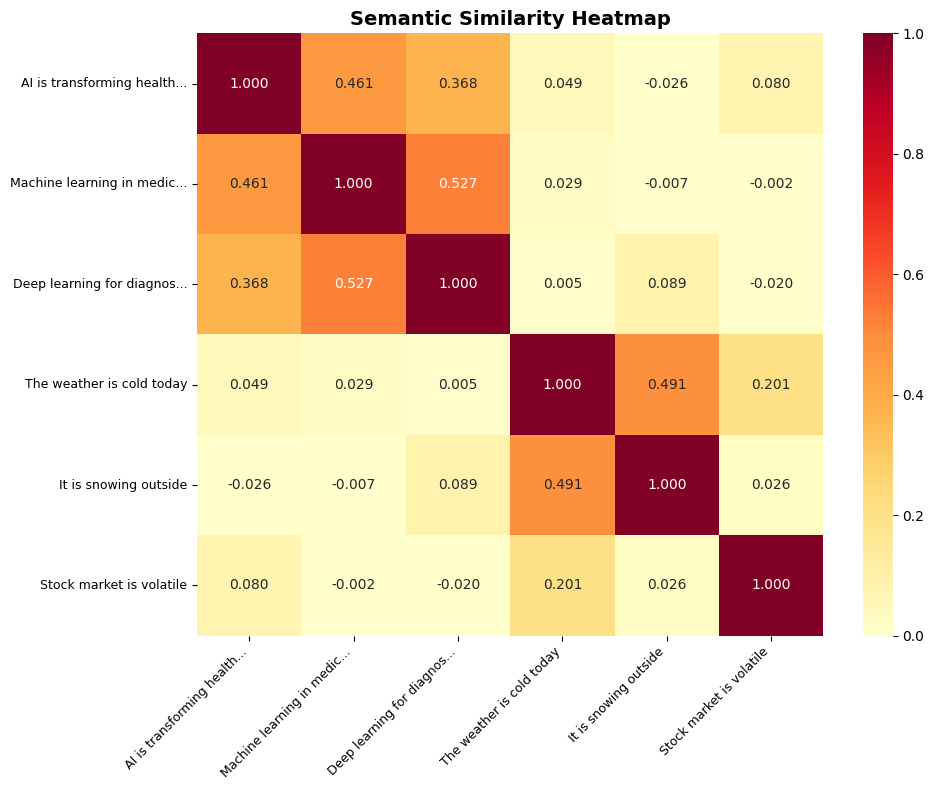


Heatmap saved as 'semantic_similarity_heatmap.png'

💡 Notice: AI/healthcare sentences cluster together, weather sentences cluster together!


In [6]:
# =============================================================
# 3.2 Semantic Similarity Heatmap
# =============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "AI is transforming healthcare",
    "Machine learning in medicine",
    "Deep learning for diagnosis",
    "The weather is cold today",
    "It is snowing outside",
    "Stock market is volatile",
]

# Generate embeddings and compute similarity matrix
embeddings = model.encode(sentences)
sim_matrix = cosine_similarity(embeddings)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=[s[:25]+"..." if len(s)>25 else s for s in sentences],
    yticklabels=[s[:25]+"..." if len(s)>25 else s for s in sentences],
    ax=ax,
    vmin=0, vmax=1
)
ax.set_title("Semantic Similarity Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("semantic_similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nHeatmap saved as 'semantic_similarity_heatmap.png'")
print("\n💡 Notice: AI/healthcare sentences cluster together, weather sentences cluster together!")


---

## 4.Transformer Architecture

### Background — "Attention Is All You Need" (Vaswani et al., 2017)

The Transformer architecture was introduced by Google in the seminal paper **"Attention Is All You Need"**. It replaced recurrent architectures (RNN, LSTM) with a mechanism called **Self-Attention**, enabling:
- **Parallel processing** (unlike sequential RNNs)
- **Long-range dependencies** (no vanishing gradient)
- **Scalability** to billions of parameters

---

### 4.1 High-Level Architecture

```
┌─────────────────────────────────────────────────────────┐
│                    TRANSFORMER                          │
│                                                         │
│   ┌─────────────┐              ┌──────────────┐        │
│   │   ENCODER   │              │   DECODER    │        │
│   │             │    ────►     │              │        │
│   │ • Self-Attn │   Context    │ • Masked     │        │
│   │ • FFN       │   Vector     │   Self-Attn  │        │
│   │ • LayerNorm │              │ • Cross-Attn │        │
│   │             │              │ • FFN        │        │
│   │  (×N layers)│              │  (×N layers) │        │
│   └─────────────┘              └──────────────┘        │
│         ▲                            │                  │
│    Input Tokens                 Output Tokens           │
│   + Positional                  + Positional            │
│     Encoding                      Encoding              │
└─────────────────────────────────────────────────────────┘
```

---

### 4.2 Self-Attention Mechanism

Self-Attention allows each token to **attend to every other token** in the sequence, enabling the model to understand relationships and context.

#### The Q, K, V Framework

For each token, we create three vectors:
- **Q (Query)**: "What am I looking for?"
- **K (Key)**: "What do I contain?"
- **V (Value)**: "What information do I provide?"

#### The Attention Formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Where:
- $QK^T$ = Dot product of Query and Key (relevance scores)
- $\sqrt{d_k}$ = Scaling factor (prevents vanishing gradients in softmax)
- $\text{softmax}$ = Converts scores to probabilities (sum = 1)
- $V$ = Weighted sum of values based on attention scores

#### Step-by-Step:
1. **Compute Q, K, V** from input embeddings using learned weight matrices
2. **Score**: Dot product of Q with all K's → relevance scores
3. **Scale**: Divide by √d_k to stabilize gradients
4. **Softmax**: Convert to attention weights (probabilities)
5. **Weighted Sum**: Multiply weights with V to get output

---

### 4.3 Multi-Head Attention

Instead of one attention function, the Transformer uses **multiple attention heads in parallel**:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(head_1, ..., head_h) W^O$$
$$\text{where } head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

**Why multiple heads?**
- Different heads can learn **different types of relationships**
- Head 1 might focus on **syntactic** relationships
- Head 2 might focus on **semantic** relationships
- Head 3 might focus on **positional** relationships
- Original Transformer: **8 heads**, GPT-3: **96 heads**

---

### 4.4 Positional Encoding

Since Transformers process all tokens **in parallel** (no sequential processing), they have **no inherent notion of word order**. Positional encodings add position information.

#### Sinusoidal Positional Encoding:

$$PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Where:
- `pos` = position in the sequence
- `i` = dimension index
- `d_model` = model dimension (e.g., 512)

---

### 4.5 Feed-Forward Network (FFN)

After attention, each position passes through a **two-layer feed-forward network**:

$$FFN(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$

- **Expansion**: First layer expands dimension (512 → 2048)
- **Contraction**: Second layer contracts back (2048 → 512)
- Applied **identically** to each position

---

### 4.6 Layer Normalization & Residual Connections

$$\text{Output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

- **Residual Connection**: Helps gradient flow in deep networks (skip connection)
- **Layer Normalization**: Stabilizes training by normalizing across features

---

### 4.7 Architecture Variants

| Variant | Architecture | Models | Use Case |
|---------|-------------|--------|----------|
| **Encoder-Only** | Only Encoder stack | BERT, RoBERTa, DistilBERT | Classification, NER, Sentiment |
| **Decoder-Only** | Only Decoder stack | GPT-2, GPT-3, GPT-4, LLaMA | Text Generation, Chatbots |
| **Encoder-Decoder** | Full Transformer | T5, BART, mBART | Translation, Summarization |

> **Fun Fact**: GPT-4 is estimated to have ~1.8 trillion parameters across 8 expert models (Mixture of Experts), while BERT-base has only 110M parameters!


In [ ]:
# =============================================================
# 4.1 Self-Attention Implementation from Scratch (PyTorch)
# =============================================================
import torch
import torch.nn.functional as F
import numpy as np

torch.manual_seed(42)

# ------- Setup -------
# Simulating 4 tokens, each with 8-dimensional embeddings
seq_len = 4
d_model = 8
d_k = d_model  # dimension of Q, K, V

# Token labels for display
tokens = ["The", "cat", "sat", "down"]

# Random input embeddings (batch_size=1, seq_len=4, d_model=8)
X = torch.randn(1, seq_len, d_model)

# Learned weight matrices (in real transformers, these are learned)
W_Q = torch.randn(d_model, d_k)
W_K = torch.randn(d_model, d_k)
W_V = torch.randn(d_model, d_k)

print("=" * 80)
print("🧮 SELF-ATTENTION MECHANISM — STEP BY STEP")
print("=" * 80)

# Step 1: Compute Q, K, V
Q = X @ W_Q  # Query
K = X @ W_K  # Key
V = X @ W_V  # Value

print(f"\n📊 Input shape     : {X.shape}")
print(f"📊 Q, K, V shape   : {Q.shape}")

# Step 2: Compute attention scores (Q @ K^T)
scores = Q @ K.transpose(-2, -1)  # (1, 4, 4)
print(f"\n📊 Raw Attention Scores (QK^T):")
print(np.round(scores[0].detach().numpy(), 3))

# Step 3: Scale by sqrt(d_k)
scale = d_k ** 0.5
scaled_scores = scores / scale
print(f"\n📊 Scaled Scores (÷ √{d_k} = {scale:.2f}):")
print(np.round(scaled_scores[0].detach().numpy(), 3))

# Step 4: Apply Softmax → Attention Weights
attention_weights = F.softmax(scaled_scores, dim=-1)
print(f"\n📊 Attention Weights (after Softmax):")
weights_np = attention_weights[0].detach().numpy()
print(np.round(weights_np, 4))

# Step 5: Weighted sum of Values
output = attention_weights @ V  # (1, 4, 8)
print(f"\n📊 Output shape    : {output.shape}")

# Display which tokens attend to which
print("\n" + "=" * 80)
print("🔍 ATTENTION PATTERN — Which token attends to which?")
print("=" * 80)
for i, token in enumerate(tokens):
    print(f"\n  '{token}' attends to:")
    for j, target in enumerate(tokens):
        weight = weights_np[i][j]
        bar = "█" * int(weight * 40)
        print(f"    → '{target}': {weight:.4f}  {bar}")


In [ ]:
# =============================================================
# 4.2 Positional Encoding — Visualization
# =============================================================
import numpy as np
import matplotlib.pyplot as plt

def get_positional_encoding(max_len, d_model):
    """Generate sinusoidal positional encoding."""
    PE = np.zeros((max_len, d_model))
    position = np.arange(0, max_len).reshape(-1, 1)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    
    PE[:, 0::2] = np.sin(position * div_term)  # Even indices
    PE[:, 1::2] = np.cos(position * div_term)  # Odd indices
    
    return PE

# Generate positional encodings
max_len = 100   # 100 positions
d_model = 128   # 128 dimensions
PE = get_positional_encoding(max_len, d_model)

# Plot heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full heatmap
im1 = axes[0].imshow(PE, cmap='RdBu', aspect='auto', interpolation='nearest')
axes[0].set_xlabel("Embedding Dimension", fontsize=11)
axes[0].set_ylabel("Position in Sequence", fontsize=11)
axes[0].set_title("Sinusoidal Positional Encoding\n(100 positions × 128 dimensions)", fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

# Selected dimensions - sine waves
dims_to_plot = [0, 4, 8, 16, 32, 64]
for d in dims_to_plot:
    axes[1].plot(PE[:, d], label=f"Dim {d}", linewidth=1.5)
axes[1].set_xlabel("Position in Sequence", fontsize=11)
axes[1].set_ylabel("Encoding Value", fontsize=11)
axes[1].set_title("Positional Encoding — Selected Dimensions", fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("positional_encoding.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPositional Encoding visualization saved!")
print("\nKey Insight:")
print("   • Lower dimensions → Higher frequency (rapid oscillation)")
print("   • Higher dimensions → Lower frequency (slower oscillation)")
print("   • Each position gets a UNIQUE encoding pattern")
print("   • Nearby positions have similar encodings (continuity)")


---

### PART B: Retrieval-Augmented Generation (RAG)

---

## 5. What is RAG?

### Definition
**Retrieval-Augmented Generation (RAG)** is a technique that enhances Large Language Models by **retrieving relevant information from external knowledge sources** before generating a response.

> 💡 **Think of RAG as**: Instead of answering from memory (which may be outdated or wrong), the LLM first **looks up information** in a knowledge base and then generates an answer using that context.

---

### Why Do LLMs Need RAG?

LLMs, despite their impressive capabilities, suffer from three critical limitations:

| Problem | Description | RAG Solution |
|---------|-------------|-------------|
| *Knowledge Cutoff** | LLMs are trained on data up to a certain date. They don't know about events after training. | RAG connects to **up-to-date** knowledge sources |
| *Hallucinations** | LLMs can generate plausible-sounding but **factually incorrect** information confidently. | RAG provides **grounded, factual** context to prevent hallucinations |
| * No Private/Domain Data** | LLMs don't have access to your company's internal documents, policies, or proprietary data. | RAG retrieves from **your organization's** knowledge base |

---

### RAG vs Traditional Approaches

| Approach | Pros | Cons |
|----------|------|------|
| **Vanilla LLM** | Simple, fast | Hallucinations, no private data, knowledge cutoff |
| **Fine-tuning** | Customized behavior | Expensive, needs labeled data, still no live updates |
| **RAG** | Grounded answers, uses any data source, updatable | Slightly more latency, retrieval quality matters |

---

### When to Use RAG?
- Enterprise chatbots (HR policies, IT support)  
- Document Q&A (legal contracts, research papers)  
- Customer support (product manuals, FAQs)  
- Medical/clinical decision support  
- Financial report analysis  
- Code documentation search  


---

## 6.RAG Architecture — Detailed Components

### End-to-End RAG Pipeline

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                        RAG ARCHITECTURE PIPELINE                            │
│                                                                              │
│  ┌─────────────┐   ┌──────────────┐   ┌─────────────┐   ┌──────────────┐  │
│  │  DOCUMENTS  │──►│   CHUNKING   │──►│  EMBEDDING  │──►│VECTOR STORE  │  │
│  │  (PDFs,     │   │  (Split into │   │  (Convert   │   │  (FAISS,     │  │
│  │   Docs,     │   │   smaller    │   │   chunks to │   │   ChromaDB,  │  │
│  │   Web,      │   │   pieces)    │   │   vectors)  │   │   Pinecone)  │  │
│  │   APIs)     │   │              │   │              │   │              │  │
│  └─────────────┘   └──────────────┘   └─────────────┘   └──────┬───────┘  │
│                                                                  │          │
│                     ════════ INDEXING PHASE ═════════            │          │
│  ═══════════════════════════════════════════════════════════════════════    │
│                     ════════ QUERY PHASE ════════════            │          │
│                                                                  │          │
│  ┌─────────────┐   ┌──────────────┐   ┌─────────────┐          │          │
│  │   USER      │──►│   QUERY      │──►│  RETRIEVAL  │◄─────────┘          │
│  │   QUERY     │   │  EMBEDDING   │   │  (Top-K     │                      │
│  │             │   │              │   │   similar)  │                      │
│  └─────────────┘   └──────────────┘   └──────┬──────┘                      │
│                                               │                             │
│                                               ▼                             │
│                                        ┌──────────────┐                    │
│                                        │   PROMPT     │                    │
│                                        │ CONSTRUCTION │                    │
│                                        │ (Context +   │                    │
│                                        │  Query)      │                    │
│                                        └──────┬───────┘                    │
│                                               │                             │
│                                               ▼                             │
│                                        ┌──────────────┐                    │
│                                        │   LLM        │                    │
│                                        │ GENERATION   │──► RESPONSE        │
│                                        │ (GPT-4,      │   (Grounded       │
│                                        │  Claude,     │    Answer with     │
│                                        │  LLaMA)      │    Citations)      │
│                                        └──────────────┘                    │
└──────────────────────────────────────────────────────────────────────────────┘
```

---

### 6.1 Document Loading & Chunking

**Document Loaders**: Read data from various sources
- PDFs (PyPDF, pdfplumber), Word docs, CSV/Excel
- Web pages (BeautifulSoup, Scrapy)
- APIs, Databases, SharePoint, Confluence

**Chunking Strategies**:

| Strategy | Description | Best For |
|----------|-----------|----------|
| **Fixed-size** | Split every N characters/tokens | Simple documents |
| **Recursive** | Split on \n\n, then \n, then space | General purpose (LangChain default) |
| **Semantic** | Split based on meaning/topic | Technical documents |
| **Sentence-based** | Split on sentence boundaries | Narrative text |

**Key Parameters**:
- **Chunk size**: 200–1000 tokens (sweet spot: ~500)
- **Chunk overlap**: 50–200 tokens (ensures context continuity)

---

### 6.2 Embedding Models

| Model | Dimensions | Speed | Quality | Provider |
|-------|-----------|-------|---------|----------|
| all-MiniLM-L6-v2 | 384 | ⚡ Fast | Good | HuggingFace |
| all-mpnet-base-v2 | 768 | Medium | Very Good | HuggingFace |
| text-embedding-ada-002 | 1536 | Medium | Excellent | OpenAI |
| text-embedding-3-large | 3072 | Slower | State-of-art | OpenAI |
| Cohere Embed v3 | 1024 | Medium | Excellent | Cohere |

---

### 6.3 Vector Databases

| Database | Type | Best For | Key Feature |
|----------|------|----------|-------------|
| **FAISS** | Library (local) | Prototyping, small-medium scale | Fast, free, by Meta |
| **ChromaDB** | Embedded DB | Development, lightweight | Simple API |
| **Pinecone** | Managed cloud | Production, enterprise | Fully managed, scalable |
| **Weaviate** | Self-hosted/cloud | Enterprise, hybrid search | GraphQL API |
| **Milvus** | Self-hosted | Large-scale production | High performance |
| **Qdrant** | Self-hosted/cloud | Production | Rust-based, fast |

---

### 6.4 Retrieval Methods

- **Dense Retrieval**: Embedding similarity (cosine, dot product)
- **Sparse Retrieval**: BM25, TF-IDF (keyword matching)
- **Hybrid Search**: Combine dense + sparse (best of both worlds)
- **ANN (Approximate Nearest Neighbor)**: HNSW, IVF for faster search at scale
- **Top-K**: Return K most similar chunks (typically K=3–5)

---

### 6.5 Prompt Construction

```
SYSTEM: You are a helpful assistant. Use ONLY the following context to answer.
If the answer is not in the context, say "I don't have enough information."

CONTEXT:
{retrieved_chunk_1}
{retrieved_chunk_2}
{retrieved_chunk_3}

USER QUESTION: {user_query}

ANSWER:
```


In [ ]:
pip install faiss-cpu

In [ ]:
pip install langchain-community

In [ ]:
# =============================================================
# 6.1 Complete RAG Pipeline Implementation using FAISS
# =============================================================
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss

print("=" * 80)
print("RAG PIPELINE — COMPLETE IMPLEMENTATION")
print("=" * 80)

# -------------------------------------------------------
# STEP 1: Define Knowledge Base (Enterprise Documents)
# -------------------------------------------------------
documents = [
    # HR Policies
    "EXL's annual leave policy allows employees to take 24 days of paid leave per year. "
    "Unused leaves can be carried forward up to a maximum of 10 days to the next calendar year. "
    "Leave requests must be submitted at least 3 business days in advance through the HR portal.",
    
    "The work-from-home policy permits employees to work remotely up to 3 days per week. "
    "Employees must ensure a stable internet connection and be available during core hours "
    "(10 AM to 4 PM IST). Manager approval is required for WFH arrangements.",
    
    "Employee health insurance covers the employee, spouse, and up to 2 dependent children. "
    "The coverage includes hospitalization, outpatient consultations, dental, and vision care. "
    "The annual coverage limit is INR 5,00,000 for the base plan and INR 10,00,000 for the premium plan.",
    
    # Training & Development
    "The Capability Development team offers monthly training programs covering AI, Cloud, "
    "Analytics, and Soft Skills. Employees can nominate themselves through reNew platform. "
    "All nominations require VP approval for functional trainings.",
    
    "AWS Cloud Practitioner certification training is offered as a 12-hour instructor-led "
    "program. Upon completion, employees receive exam vouchers for the certification exam. "
    "The training covers cloud concepts, security, pricing, and AWS core services.",
    
    "The Adobe Analytics training program is a 30-hour course covering modern analytics "
    "implementation using AEP Web SDK, Analysis Workspace, segmentation, and data governance. "
    "The program includes hands-on labs and a capstone project.",
    
    # IT Policies
    "Password policy requires all employees to change their passwords every 90 days. "
    "Passwords must be at least 12 characters long, contain uppercase, lowercase, numbers, "
    "and special characters. Multi-factor authentication (MFA) is mandatory for all systems.",
    
    "Software installation on company laptops requires IT team approval through the ServiceNow "
    "portal. Only approved software from the company's software catalog can be installed. "
    "Unauthorized software installation is a violation of IT security policy.",
    
    # Performance & Compensation
    "Annual performance reviews are conducted in March-April. The review process includes "
    "self-assessment, manager evaluation, calibration, and feedback sessions. Ratings are "
    "on a 5-point scale: Exceptional, Exceeds Expectations, Meets Expectations, Needs Improvement, Unsatisfactory.",
    
    "The company offers a variable pay component that ranges from 10% to 20% of the annual "
    "CTC based on individual performance rating and company-level achievement of business targets. "
    "Variable pay is disbursed annually in June."
]

print(f"\n📚 Knowledge Base: {len(documents)} documents loaded")
for i, doc in enumerate(documents):
    print(f"   Doc {i+1}: {doc[:80]}...")

# -------------------------------------------------------
# STEP 2: Chunking (documents are already appropriately sized)
# -------------------------------------------------------
print(f"\n✂️  Chunking: Documents already at optimal chunk size (~100-150 words each)")
chunks = documents  # In production, you'd use RecursiveCharacterTextSplitter

# -------------------------------------------------------
# STEP 3: Generate Embeddings
# -------------------------------------------------------
print("\n📐 Generating embeddings using 'all-MiniLM-L6-v2'...")
model = SentenceTransformer('all-MiniLM-L6-v2')
chunk_embeddings = model.encode(chunks, show_progress_bar=False)
print(f"   Embedding shape: {chunk_embeddings.shape} (chunks × dimensions)")

# -------------------------------------------------------
# STEP 4: Store in FAISS Vector Index
# -------------------------------------------------------
dimension = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner Product (cosine similarity with normalized vectors)

# Normalize embeddings for cosine similarity
faiss.normalize_L2(chunk_embeddings)
index.add(chunk_embeddings.astype('float32'))

print(f"\nFAISS Index created with {index.ntotal} vectors (dimension={dimension})")
print("\nIndexing Phase Complete!")


In [ ]:
# =============================================================
# 6.2 RAG Query Phase — Retrieval & Response Generation
# =============================================================

def rag_query(question, model, index, chunks, top_k=3):
    """
    Complete RAG pipeline: Query → Embed → Retrieve → Construct Prompt
    """
    print(f"\n{'='*80}")
    print(f"❓ USER QUERY: \"{question}\"")
    print(f"{'='*80}")
    
    # Step 1: Embed the query
    query_embedding = model.encode([question])
    faiss.normalize_L2(query_embedding)
    
    # Step 2: Search FAISS index for top-k similar chunks
    scores, indices = index.search(query_embedding.astype('float32'), top_k)
    
    # Step 3: Retrieve relevant chunks
    print(f"\n📥 RETRIEVED CONTEXT (Top-{top_k} chunks):")
    print("-" * 60)
    retrieved_chunks = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        chunk = chunks[idx]
        retrieved_chunks.append(chunk)
        print(f"\n  🏷️  Rank {rank+1} | Score: {score:.4f} | Doc #{idx+1}")
        print(f"     {chunk[:120]}...")
    
    # Step 4: Construct Augmented Prompt
    context = "\n\n".join([f"[Document {i+1}]: {c}" for i, c in enumerate(retrieved_chunks)])
    
    augmented_prompt = f"""You are a helpful enterprise assistant. Answer the question using ONLY the 
provided context. If the answer is not in the context, say "I don't have enough information."

CONTEXT:
{context}

QUESTION: {question}

ANSWER:"""
    
    print(f"\n📝 AUGMENTED PROMPT (sent to LLM):")
    print("-" * 60)
    print(augmented_prompt)
    
    return augmented_prompt, retrieved_chunks, scores[0]

# -------------------------------------------------------
# Test with multiple queries
# -------------------------------------------------------
queries = [
    "How many days of annual leave do employees get?",
    "What certifications are available for cloud computing?",
    "What is the password policy?",
    "Tell me about the health insurance coverage.",
    "When are performance reviews conducted?",
]

for query in queries:
    prompt, chunks_retrieved, scores = rag_query(query, model, index, chunks, top_k=3)
    print("\n" + "🟢" * 40)


---

## 7.Advanced RAG Techniques

### 7.1 Multi-Query Retrieval
Instead of using the original query directly, generate **multiple reformulated queries** to capture different aspects of the user's intent:

```
Original: "What are the benefits of RAG?"
Query 1: "Advantages of retrieval augmented generation"
Query 2: "Why use RAG over fine-tuning?"
Query 3: "RAG benefits for enterprise applications"
```
Then retrieve for ALL queries and merge/deduplicate results.

---

### 7.2 Re-Ranking
After initial retrieval, use a **cross-encoder** to re-rank the results for higher precision:

```
Step 1: Retrieve top-20 using bi-encoder (fast but approximate)
Step 2: Re-rank top-20 using cross-encoder (slow but precise)
Step 3: Select top-3 for context
```

Popular re-rankers: **Cohere Rerank**, **cross-encoder/ms-marco-MiniLM-L-12**

---

### 7.3 Hybrid Search
Combine **semantic search** (dense embeddings) with **keyword search** (BM25/TF-IDF):

$$\text{Final Score} = \alpha \times \text{Semantic Score} + (1-\alpha) \times \text{BM25 Score}$$

This catches both **meaning-based** and **exact keyword** matches.

---

### 7.4 Query Expansion & HyDE
- **Query Expansion**: Add related terms to the query
- **HyDE (Hypothetical Document Embeddings)**: Ask the LLM to generate a hypothetical answer, then use THAT to search (often finds better matches)

---

### 7.5 Contextual Compression
After retrieval, **compress** the retrieved chunks to extract only the relevant portions, reducing noise in the context.

---

## 8. RAG vs Fine-Tuning — When to Use What?

| Criteria | RAG | Fine-Tuning |
|----------|-----|-------------|
| **Cost** | Lower (no training needed) | Higher (GPU training required) |
| **Data Requirements** | Any documents, no labeling | Labeled training data needed |
| **Knowledge Updates** | ✅ Real-time (just update docs) | ❌ Requires retraining |
| **Hallucination Control** | ✅ Grounded in retrieved context | ⚠️ Can still hallucinate |
| **Domain Adaptation** | Good for factual Q&A | Better for style/behavior change |
| **Latency** | Higher (retrieval + generation) | Lower (single inference) |
| **Best For** | Document Q&A, enterprise chatbots | Custom tone, specialized tasks |

> 💡 **Pro Tip**: In practice, **RAG + Fine-Tuning together** gives the best results — Fine-tune for domain style, RAG for factual accuracy.

---

### 9. RAG Evaluation — RAGAS Framework

| Metric | What It Measures | Range |
|--------|-----------------|-------|
| **Faithfulness** | Is the answer supported by the context? | 0–1 |
| **Answer Relevancy** | Is the answer relevant to the question? | 0–1 |
| **Context Precision** | Are retrieved docs relevant to the question? | 0–1 |
| **Context Recall** | Does the context contain all info needed? | 0–1 |

```python
# Using RAGAS framework
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision

result = evaluate(dataset, metrics=[faithfulness, answer_relevancy, context_precision])
```


---

### 10.Summary & Key Takeaways

### Tokens
- Tokens are the fundamental units processed by LLMs
- BPE (Byte-Pair Encoding) is the most common tokenization method
- 1 token ≈ 4 characters ≈ 0.75 words in English

### Embeddings
- Dense vector representations capturing semantic meaning
- Contextual embeddings (BERT, Sentence-BERT) outperform static ones (Word2Vec)
- Cosine similarity measures how close two embeddings are

### Transformer Architecture
- **Self-Attention**: Attention(Q,K,V) = softmax(QK^T/√d_k) × V
- **Multi-Head Attention**: Multiple parallel attention heads for diverse patterns
- **Positional Encoding**: Sinusoidal functions to encode word order
- **Variants**: Encoder-only (BERT), Decoder-only (GPT), Encoder-Decoder (T5)

### RAG Architecture
- **Indexing**: Documents → Chunks → Embeddings → Vector Store
- **Querying**: Query → Embed → Retrieve → Augment Prompt → LLM → Response
- **Key Components**: Embeddings model, Vector DB, Retrieval strategy, LLM
- **Advantages**: No hallucinations, real-time knowledge, uses private data

### Advanced RAG
- Multi-query retrieval, re-ranking, hybrid search, HyDE
- RAG + Fine-tuning = best of both worlds
- RAGAS framework for evaluation

---

### Recommended Resources
1. [Attention Is All You Need (Original Paper)](https://arxiv.org/abs/1706.03762)
2. [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805)
3. [RAG: Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks](https://arxiv.org/abs/2005.11401)
4. [LangChain Documentation](https://docs.langchain.com/)
5. [FAISS Documentation](https://faiss.ai/)
6. [Sentence Transformers](https://www.sbert.net/)

---

